In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [ ]:
import torch
import psutil
import os

print("="*50)
print("       SYSTEM INFRASTRUCTURE REPORT")
print("="*50)

print("\n[Hardware Core - GPU]")
if torch.cuda.is_available():
    print(f"Entity: {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Attributes: {vram:.2f} GB GDDR6 VRAM")
else:
    print("Entity: No GPU detected or CUDA not configured.")

print("\n[System Memory - RAM]")
ram = psutil.virtual_memory().total / (1024**3)
print(f"Entity: Random Access Memory (RAM)")
print(f"Attributes: {ram:.2f} GB System Allocation")

print("\n[Core Framework]")
print(f"Engine: PyTorch Framework Architecture")
print(f"Version: {torch.__version__}")

print("\n[Parallel Computing Platform]")
print(f"Ecosystem: NVIDIA CUDA Ecosystem")
print(f"Version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print("="*50)

In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))


GPU Available: True
Device Name: NVIDIA GeForce RTX 4090


In [2]:
import os

class Config:
    #BASE_DIR = "/content/drive/MyDrive/Thesis_dataset"
    BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

    DATASET_DIR = os.path.join(BASE_DIR, "dataset/chunks")
    SPLIT_DIR = os.path.join(BASE_DIR, "dataset/splits")

    MODEL_DIR = os.path.join(BASE_DIR, "models")
    OUTPUT_DIR = os.path.join(BASE_DIR, "output")

    TRAIN_CSV = os.path.join(SPLIT_DIR, "train.csv")
    TEST_CSV = os.path.join(SPLIT_DIR, "test.csv")
    VAL_CSV = os.path.join(SPLIT_DIR, "val.csv")
    METADATA = os.path.join(BASE_DIR, "dataset/metadata.csv")

    SAMPLE_RATE = 16000
    BATCH_SIZE = 16
    EPOCHS = 25
    LR = 5e-5

    MODEL_NAME = "openai/whisper-small"

# Main

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

cfg = Config()

df = pd.read_csv(cfg.METADATA)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["region"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["region"]
)

# save
os.makedirs(cfg.SPLIT_DIR, exist_ok=True)

train_df.to_csv(cfg.TRAIN_CSV, index=False)
val_df.to_csv(cfg.VAL_CSV, index=False)
test_df.to_csv(cfg.TEST_CSV, index=False)

print("Stratified Split Done!")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Stratified Split Done!
Train: 5320
Val: 665
Test: 665


In [4]:
import pandas as pd

train_df = pd.read_csv(cfg.TRAIN_CSV)
val_df = pd.read_csv(cfg.VAL_CSV)
test_df = pd.read_csv(cfg.TEST_CSV)

summary = pd.DataFrame({
    "Train": train_df["region"].value_counts(),
    "Validation": val_df["region"].value_counts(),
    "Test": test_df["region"].value_counts()
}).fillna(0).astype(int)

print(summary)

            Train  Validation  Test
region                             
barishal     1064         133   133
chittagong   1064         133   133
noakhali     1064         133   133
rangpur      1064         133   133
sylhet       1064         133   133


In [5]:
import numpy as np

def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

In [ ]:
! pip install librosa

In [6]:
from torch.utils.data import Dataset
import librosa

class WhisperDataset(Dataset):

    def __init__(self, csv_file, config, processor, augment=False):

        self.df = pd.read_csv(csv_file)

        self.cfg = config
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def load_audio(self, path):

        audio, sr = librosa.load(
            path,
            sr=self.cfg.SAMPLE_RATE
        )

        # remove NaN
        audio = np.nan_to_num(audio)

        # LIMIT LENGTH (VERY IMPORTANT)
        audio = audio[:self.cfg.SAMPLE_RATE * 10]

        return audio

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = os.path.join(
            self.cfg.BASE_DIR,
            row["audio_path"]
        )

        # check file
        if not os.path.exists(path):
            raise FileNotFoundError(path)

        audio = self.load_audio(path)

        # FAST AUGMENTATION
        if self.augment:
            if np.random.rand() < 0.6:
                audio = add_noise(audio)

        # feature extraction
        input_features = self.processor.feature_extractor(
            audio,
            sampling_rate=self.cfg.SAMPLE_RATE,
            return_tensors="pt"
        ).input_features[0]

        # labels
        labels = self.processor.tokenizer(
            row["transcript"],
            return_tensors="pt"
        ).input_ids.squeeze()

        return {
            "input_features": input_features,
            "labels": labels,
            "region": row["region"]
        }

In [7]:
def collate_fn(batch):

    input_features = torch.stack(
        [b["input_features"] for b in batch]
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        [b["labels"] for b in batch],
        batch_first=True,
        padding_value=-100
    )

    regions = [b["region"] for b in batch]

    return {
        "input_features": input_features,
        "labels": labels,
        "region": regions
    }

In [8]:
from transformers import WhisperProcessor
from transformers import WhisperForConditionalGeneration

processor = WhisperProcessor.from_pretrained(cfg.MODEL_NAME)

model = WhisperForConditionalGeneration.from_pretrained(
    cfg.MODEL_NAME
)

model.config.use_cache = False

# force bangla
model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="bn",
    task="transcribe"
)

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

print("Device:", device)


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Device: cuda


In [9]:
from torch.utils.data import DataLoader

train_ds = WhisperDataset(
    cfg.TRAIN_CSV,
    cfg,
    processor,
    augment=False
)

val_ds = WhisperDataset(
    cfg.VAL_CSV,
    cfg,
    processor,
    augment=False
)

test_ds = WhisperDataset(
    cfg.TEST_CSV, 
    cfg, 
    processor, 
    augment=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    num_workers=0,
    collate_fn=collate_fn
)


In [10]:
df = pd.read_csv(cfg.TRAIN_CSV)

missing = []

for path in df["audio_path"]:

    full_path = os.path.join(cfg.BASE_DIR, path)

    if not os.path.exists(full_path):
        missing.append(full_path)

print("Missing Files:", len(missing))

if len(missing) > 0:
    print(missing[:10])

Missing Files: 0


In [11]:
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup 

train_losses = []
val_losses = []

optimizer = optim.AdamW(
    model.parameters(),
    lr=cfg.LR,
    weight_decay=0.01
)

num_training_steps = len(train_loader) * cfg.EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=500,
    num_training_steps=num_training_steps
)

best_loss = float("inf")
patience = 5  
patience_counter = 0

os.makedirs(cfg.MODEL_DIR, exist_ok=True)

for epoch in range(cfg.EPOCHS):

    print("🚀 Epoch:", epoch + 1)

    if epoch < 3:
        print("Encoder Frozen for stabilization.")
        for param in model.model.encoder.parameters():
            param.requires_grad = False
    else:
        print("Encoder Unfrozen.")
        for param in model.model.encoder.parameters():
            param.requires_grad = True
            
    model.train()

    total_loss = 0

    progress_bar = tqdm(train_loader)

    for step, batch in enumerate(progress_bar):

        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k != "region"
        }

        outputs = model(**batch)

        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        progress_bar.set_postfix({
            "loss": loss.item()
        })

    avg_train_loss = total_loss / len(train_loader)

    print("Train Loss:", avg_train_loss)


    # VALIDATION
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for batch in tqdm(val_loader):

            batch = {
                k: v.to(device)
                for k, v in batch.items()
                if k != "region"
            }

            outputs = model(**batch)

            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print("Val Loss:", avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        patience_counter = 0
        # Best Weights Save
        checkpoint_path = os.path.join(cfg.MODEL_DIR, "best_whisper_model.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, checkpoint_path)
        print(f"Best model saved with Val Loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        print(f"Loss didn't improve. Early stopping counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered. Training terminated!")
        break
    
    # SAVE LAST MODEL
    torch.save(
        model.state_dict(),
        os.path.join(
            cfg.MODEL_DIR,
            "whisper_last.pth"
        )
    )

    

🚀 Epoch: 1
Encoder Frozen for stabilization.


  0%|          | 0/333 [00:00<?, ?it/s]c:\Users\USER\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
100%|██████████| 333/333 [03:15<00:00,  1.71it/s, loss=0.634]


Train Loss: 1.006160505720087


100%|██████████| 42/42 [00:20<00:00,  2.09it/s]


Val Loss: 0.5022089765185401
Best model saved with Val Loss: 0.5022
🚀 Epoch: 2
Encoder Frozen for stabilization.


...

Val Loss: 0.14506393994781233
Loss didn't improve. Early stopping counter: 4/5
🚀 Epoch: 12
Encoder Unfrozen.


100%|██████████| 333/333 [06:03<00:00,  1.09s/it, loss=0.00103]


Train Loss: 0.008114661309971578


100%|██████████| 42/42 [00:18<00:00,  2.22it/s]

Val Loss: 0.153474128938147
Loss didn't improve. Early stopping counter: 5/5
Early stopping triggered. Training terminated!


Loss curve graph successfully saved at: d:\TEAM_34\output\loss_curve.png


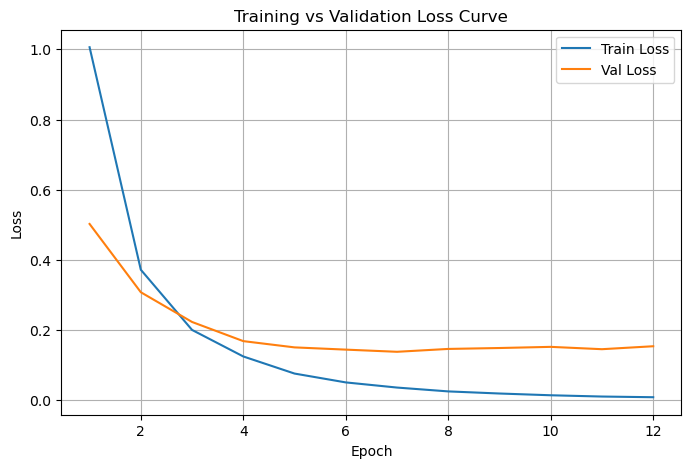

In [12]:
import os
import matplotlib.pyplot as plt

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()

save_path = os.path.join(cfg.OUTPUT_DIR, "loss_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
print(f"Loss curve graph successfully saved at: {save_path}")

plt.show()

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs[:12], train_losses[:12], label="Train Loss")
plt.plot(epochs[:12], val_losses[:12], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
! pip install --upgrade pyarrow numpy --force-reinstall

In [ ]:
! pip install evaluate
! pip install jiwer evaluate

In [13]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import evaluate

model_path = "models/best_whisper_model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = cfg.MODEL_NAME

processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="bn",
    task="transcribe"
)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

print("Whisper model loaded")

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

print("Metrics Loaded")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper model loaded
Metrics Loaded


In [14]:
import re

def clean_bengali_text(text):
    text = re.sub(r'[।,;:!?•\'"()\[\]{}—\-_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
def evaluate_model(loader):
    model.eval()

    preds = []
    refs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch["input_features"].to(device)

            generated = model.generate(inputs)

            # predictions
            pred_text = processor.tokenizer.batch_decode(
                generated,
                skip_special_tokens=True
            )

            labels = batch["labels"]

            labels = labels.clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id

            ref_text = processor.tokenizer.batch_decode(
                labels,
                skip_special_tokens=True
            )

            cleaned_pred_text = [clean_bengali_text(t) for t in pred_text]
            cleaned_ref_text = [clean_bengali_text(t) for t in ref_text]

            preds.extend(cleaned_pred_text)
            refs.extend(cleaned_ref_text)
            
    wer = wer_metric.compute(predictions=preds, references=refs)
    cer = cer_metric.compute(predictions=preds, references=refs)
    
    word_accuracy = (1 - wer) * 100
    char_accuracy = (1 - cer) * 100

    return wer, cer, word_accuracy, char_accuracy

In [17]:
import os
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

wer, cer, w_acc, c_acc = evaluate_model(test_loader)

print("FINAL RESULT")
print("FINAL TEST DATA RESULT")
print(f"Word Error Rate (WER)     : {wer:.4f}")
print(f"Character Error Rate (CER): {cer:.4f}")
print(f"Word Accuracy (WAcc)      : {w_acc:.2f}%") 
print(f"Character Accuracy (CAcc) : {c_acc:.2f}%") 

txt_save_path = os.path.join(cfg.OUTPUT_DIR, "evaluation_results.txt")

with open(txt_save_path, "w", encoding="utf-8") as f:
    f.write("FINAL RESULT\n")
    f.write("FINAL TEST DATA RESULT\n")
    f.write(f"Word Error Rate (WER)     : {wer:.4f}\n")
    f.write(f"Character Error Rate (CER): {cer:.4f}\n")
    f.write(f"Word Accuracy (WAcc)      : {w_acc:.2f}%\n")
    f.write(f"Character Accuracy (CAcc) : {c_acc:.2f}%\n")

print(f"\nEvaluation results successfully saved as text file at: {txt_save_path}")

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its para

FINAL RESULT
FINAL TEST DATA RESULT
Word Error Rate (WER)     : 0.4511
Character Error Rate (CER): 0.3401
Word Accuracy (WAcc)      : 54.89%
Character Accuracy (CAcc) : 65.99%

Evaluation results successfully saved as text file at: d:\TEAM_34\output\evaluation_results.txt


In [18]:
from jiwer import wer as jiwer_wer
from collections import defaultdict
import os

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

region_refs = defaultdict(list)
region_preds = defaultdict(list)

model.eval()

with torch.no_grad():
    for batch in test_loader: 
        region = batch["region"] 
        input_features = batch["input_features"].to(device)

        generated_ids = model.generate(input_features=input_features)

        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels = batch["labels"]
        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)

        for r, pred, ref in zip(region, preds, refs):
            region_preds[r].append(clean_bengali_text(pred))
            region_refs[r].append(clean_bengali_text(ref))

regional_txt_path = os.path.join(cfg.OUTPUT_DIR, "regional_accuracy_report.txt")

print("\nREGIONAL ACCURACY REPORT")

with open(regional_txt_path, "w", encoding="utf-8") as f:
    f.write("REGIONAL ACCURACY REPORT\n")
    f.write("=========================\n\n")
    
    for region in region_refs:
        region_wer = jiwer_wer(region_refs[region], region_preds[region])
        region_w_acc = max(0, (1 - region_wer) * 100) 
        
        print(f"{region}:")
        print(f"   - WER      : {region_wer:.4f}")
        print(f"   - Accuracy : {region_w_acc:.2f}%")
        
        f.write(f"{region}:\n")
        f.write(f"   - WER      : {region_wer:.4f}\n")
        f.write(f"   - Accuracy : {region_w_acc:.2f}%\n\n")

print(f"\nRegional accuracy report successfully saved as a separate text file at: {regional_txt_path}")


REGIONAL ACCURACY REPORT
chittagong:
   - WER      : 0.4019
   - Accuracy : 59.81%
sylhet:
   - WER      : 0.3451
   - Accuracy : 65.49%
barishal:
   - WER      : 0.3492
   - Accuracy : 65.08%
rangpur:
   - WER      : 0.4706
   - Accuracy : 52.94%
noakhali:
   - WER      : 0.6934
   - Accuracy : 30.66%

Regional accuracy report successfully saved as a separate text file at: d:\TEAM_34\output\regional_accuracy_report.txt
